# Algoritmos Genéticos



In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt


## Ejercicio 1

**Enunciado:** Maximizar la función $f(x) = x \cdot \sin(10\pi x) + 1$, con $x \in [0,1]$.

**Diseño del AG:**

1. **Problema:** encontrar el valor de $x \in [0,1]$ que maximiza $f(x)$.
2. **Representación:** cromosoma binario de $l=20$ bits, que se decodifica a un valor real en $[0,1]$
3. **Operadores:** selección por ruleta, cruce en un punto, mutación bit a bit — los mismos operadores del AGS visto en clase.
4. **Función de aptitud:** como $f(x)$ es siempre positiva en $[0,1]$ (varía entre 0 y 2), se usa directamente como aptitud, sin necesidad de transformarla.
5. **Criterio de parada:** número fijo de generaciones ($M=100$).
6. **Otros parámetros:** población $K=40$, probabilidad de mutación $p_m=0.01$.


In [ ]:
# Parámetros del AG
l = 20          # número de bits del cromosoma (precisión)
K = 40          # tamaño de la población
M = 100         # número de generaciones
p_mut = 0.01    # probabilidad de mutación

def f(x):
    """Función objetivo a maximizar"""
    return x * np.sin(10 * np.pi * x) + 1


In [ ]:
def genera(l, K):
    """Genera K cromosomas binarios de longitud l (lanzamiento de moneda)"""
    return [np.random.randint(0, 2, l).tolist() for _ in range(K)]

def decodifica(crom, l):
    """Convierte el cromosoma binario (genotipo) en un valor real x en [0,1] (fenotipo)"""
    xi, xf = 0.0, 1.0
    valor_decimal = int("".join(map(str, crom)), 2)
    return xi + (xf - xi) * valor_decimal / (2**l - 1)

def eval_apt(pob, l):
    """Evalúa la aptitud de cada cromosoma y su probabilidad de selección"""
    apt_crom = [f(decodifica(c, l)) for c in pob]
    apt_pob = sum(apt_crom)
    probab = [a / apt_pob for a in apt_crom]
    return apt_crom, probab

def seleccion(pob, probab):
    """Selección por ruleta"""
    K = len(pob)
    limite = 2 * max(probab)
    pob_nueva = []
    while len(pob_nueva) < K:
        i = random.randint(0, K - 1)
        aleat = random.uniform(0, limite)
        if probab[i] > aleat:
            pob_nueva.append(pob[i])
    return pob_nueva

def cruce(pob_nueva):
    """Cruce en un punto, por parejas consecutivas"""
    hijos = []
    K = len(pob_nueva)
    for i in range(0, K - 1, 2):
        crom1, crom2 = pob_nueva[i], pob_nueva[i + 1]
        pt = random.randint(1, len(crom1) - 1)
        hijos.append(crom1[:pt] + crom2[pt:])
        hijos.append(crom2[:pt] + crom1[pt:])
    if K % 2 == 1:
        hijos.append(pob_nueva[-1])
    return hijos

def mutacion(hijos, p_mut, l):
    """Mutación bit a bit con probabilidad p_mut"""
    for crom in hijos:
        for i in range(l):
            if random.random() < p_mut:
                crom[i] = 1 - crom[i]
    return hijos


In [ ]:
def Alg_Genetico(l, M, K, p_mut):
    pob = genera(l, K)
    mejor_hist = []
    for gen in range(M):
        apt_crom, probab = eval_apt(pob, l)
        mejor_idx = int(np.argmax(apt_crom))
        mejor_hist.append(apt_crom[mejor_idx])
        padres = seleccion(pob, probab)
        hijos = cruce(padres)
        pob = mutacion(hijos, p_mut, l)
    apt_crom, probab = eval_apt(pob, l)
    mejor_idx = int(np.argmax(apt_crom))
    mejor_x = decodifica(pob[mejor_idx], l)
    return mejor_x, apt_crom[mejor_idx], mejor_hist

mejor_x, mejor_apt, historial = Alg_Genetico(l, M, K, p_mut)
print(f"Mejor x encontrado: {mejor_x:.5f}")
print(f"Valor de f(x): {mejor_apt:.5f}")


Mejor x encontrado: 0.84519
Valor de f(x): 1.83555


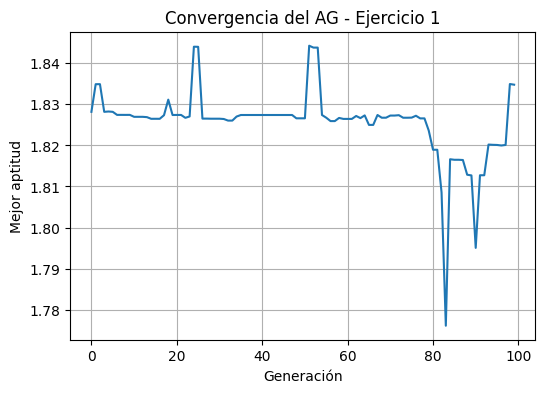

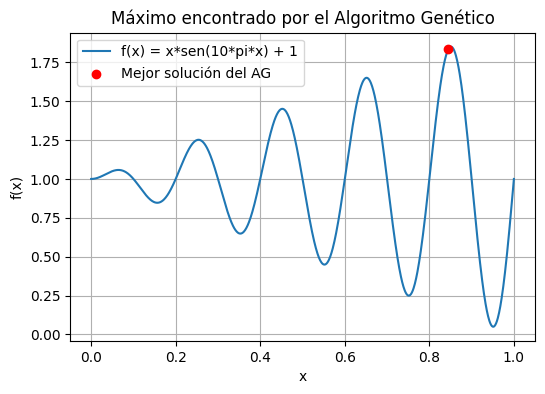

In [ ]:
# Convergencia del AG
plt.figure(figsize=(6,4))
plt.plot(historial)
plt.xlabel("Generación")
plt.ylabel("Mejor aptitud")
plt.title("Convergencia del AG - Ejercicio 1")
plt.grid(True)
plt.show()

# Función y mejor solución encontrada
xs = np.linspace(0, 1, 1000)
plt.figure(figsize=(6,4))
plt.plot(xs, f(xs), label="f(x) = x*sen(10*pi*x) + 1")
plt.scatter([mejor_x], [mejor_apt], color="red", zorder=5, label="Mejor solución del AG")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.title("Máximo encontrado por el Algoritmo Genético")
plt.grid(True)
plt.show()


La función tiene varios máximos locales debido al término $\sin(10\pi x)$; el máximo global se encuentra cerca de $x \approx 0.85$, con $f(x) \approx 1.85$. El AG lo encuentra sin necesidad de calcular derivadas ni recorrer todo el dominio, gracias a la combinación de selección, cruce y mutación.

## Ejercicio 2 — "Verdadera democracia"

**Enunciado:** Como jefe de gobierno, debe repartir el poder (ministerios y otras agencias del Estado) entre 5 partidos del congreso, con base en la representación (curules) de cada uno. Hay 50 curules distribuidas de forma no uniforme entre los 5 partidos, y 50 entidades estatales, cada una con un peso político (1 a 100 puntos). Se debe construir una matriz de poder que reparta esas entidades entre los partidos usando un AG.

**Interpretación del problema:** cada partido debería recibir un poder total (suma de pesos de las entidades que se le asignen) proporcional a su número de curules. El AG debe encontrar una asignación de las 50 entidades a los 5 partidos que minimice la diferencia entre el poder recibido y el poder que le correspondería proporcionalmente.

**Diseño del AG:**

1. **Problema:** asignar 50 entidades a 5 partidos, de forma que el poder de cada partido sea lo más cercano posible a su cuota proporcional de curules.
2. **Representación:** cromosoma de 50 genes (uno por entidad), cada gen es un entero entre 0 y 4 que indica a qué partido se asigna esa entidad. (A diferencia del ejercicio 1, aquí los genes no son binarios sino enteros, como lo menciona la sección 3.8.3 del documento sobre operadores para distintos tipos de datos).
3. **Operadores:** selección por ruleta, cruce en un punto (igual que antes, pero sobre listas de enteros), mutación que reasigna una entidad a un partido aleatorio.
4. **Función de aptitud:** se calcula el poder total de cada partido según la asignación, se compara con el poder objetivo (proporcional a las curules) y se penaliza la diferencia absoluta total. La aptitud es $1/(1+\text{error})$, así que entre más cercana esté la asignación al reparto proporcional, mayor la aptitud.
5. **Criterio de parada:** número fijo de generaciones ($M=300$).
6. **Otros parámetros:** población $K=60$, probabilidad de mutación $p_m=0.02$.


In [ ]:
n_partidos = 5
n_entidades = 50

def genera_curules(n_partidos, total=50):
    """Distribución no uniforme de 50 curules entre los partidos"""
    cortes = sorted(random.sample(range(1, total), n_partidos - 1))
    cortes = [0] + cortes + [total]
    curules = [cortes[i+1] - cortes[i] for i in range(n_partidos)]
    return curules

curules = genera_curules(n_partidos)
print("Curules por partido:", curules, "-> Total:", sum(curules))

# Peso político aleatorio de cada entidad (1 a 100 puntos)
pesos_entidades = [random.randint(1, 100) for _ in range(n_entidades)]
poder_total = sum(pesos_entidades)
print("Poder político total a repartir:", poder_total)

# Poder objetivo por partido, proporcional a sus curules
target = [poder_total * c / sum(curules) for c in curules]
print("Poder objetivo por partido:", [round(t, 2) for t in target])


Curules por partido: [1, 10, 27, 7, 5] -> Total: 50
Poder político total a repartir: 2738
Poder objetivo por partido: [54.76, 547.6, 1478.52, 383.32, 273.8]


In [ ]:
l = n_entidades   # un gen por entidad
K = 60            # tamaño de la población
M = 300           # generaciones
p_mut = 0.02

def genera(K, l, n_partidos):
    return [[random.randint(0, n_partidos - 1) for _ in range(l)] for _ in range(K)]

def poder_por_partido(crom, pesos, n_partidos):
    """Suma el poder de las entidades asignadas a cada partido"""
    poder = [0] * n_partidos
    for i, partido in enumerate(crom):
        poder[partido] += pesos[i]
    return poder

def evalua(crom, pesos, target, n_partidos):
    poder = poder_por_partido(crom, pesos, n_partidos)
    error = sum(abs(poder[i] - target[i]) for i in range(n_partidos))
    return 1 / (1 + error)   # mayor aptitud cuanto menor el error

def eval_apt(pob, pesos, target, n_partidos):
    apt_crom = [evalua(c, pesos, target, n_partidos) for c in pob]
    apt_pob = sum(apt_crom)
    probab = [a / apt_pob for a in apt_crom]
    return apt_crom, probab

def seleccion(pob, probab):
    K = len(pob)
    limite = 2 * max(probab)
    pob_nueva = []
    while len(pob_nueva) < K:
        i = random.randint(0, K - 1)
        if probab[i] > random.uniform(0, limite):
            pob_nueva.append(pob[i][:])
    return pob_nueva

def cruce(pob_nueva):
    hijos = []
    K = len(pob_nueva)
    for i in range(0, K - 1, 2):
        crom1, crom2 = pob_nueva[i], pob_nueva[i + 1]
        pt = random.randint(1, len(crom1) - 1)
        hijos.append(crom1[:pt] + crom2[pt:])
        hijos.append(crom2[:pt] + crom1[pt:])
    if K % 2 == 1:
        hijos.append(pob_nueva[-1])
    return hijos

def mutacion(hijos, p_mut, n_partidos):
    """Reasigna, con probabilidad p_mut, una entidad a un partido aleatorio distinto"""
    for crom in hijos:
        for i in range(len(crom)):
            if random.random() < p_mut:
                crom[i] = random.randint(0, n_partidos - 1)
    return hijos


In [ ]:
def Alg_Genetico_Democracia(K, M, p_mut, pesos, target, n_partidos, l):
    pob = genera(K, l, n_partidos)
    mejor_hist = []
    for gen in range(M):
        apt_crom, probab = eval_apt(pob, pesos, target, n_partidos)
        mejor_idx = int(np.argmax(apt_crom))
        mejor_hist.append(apt_crom[mejor_idx])
        padres = seleccion(pob, probab)
        hijos = cruce(padres)
        pob = mutacion(hijos, p_mut, n_partidos)
    apt_crom, probab = eval_apt(pob, pesos, target, n_partidos)
    mejor_idx = int(np.argmax(apt_crom))
    return pob[mejor_idx], apt_crom[mejor_idx], mejor_hist

mejor_crom, mejor_apt, historial2 = Alg_Genetico_Democracia(
    K, M, p_mut, pesos_entidades, target, n_partidos, l)

poder_final = poder_por_partido(mejor_crom, pesos_entidades, n_partidos)
print("Poder final por partido:      ", poder_final)
print("Poder objetivo por partido:   ", [round(t, 2) for t in target])
print("Aptitud de la mejor solución:", round(mejor_apt, 5))


Poder final por partido:       [53, 551, 1474, 385, 275]
Poder objetivo por partido:    [54.76, 547.6, 1478.52, 383.32, 273.8]
Aptitud de la mejor solución: 0.07375


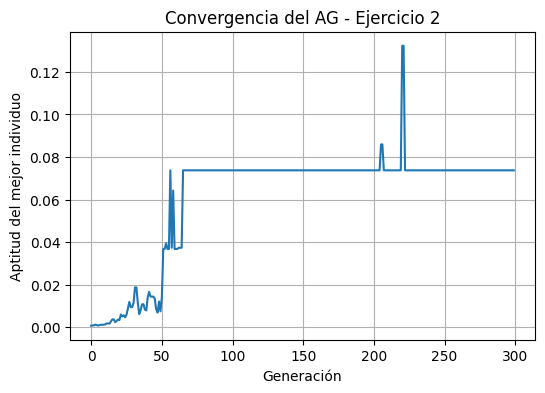

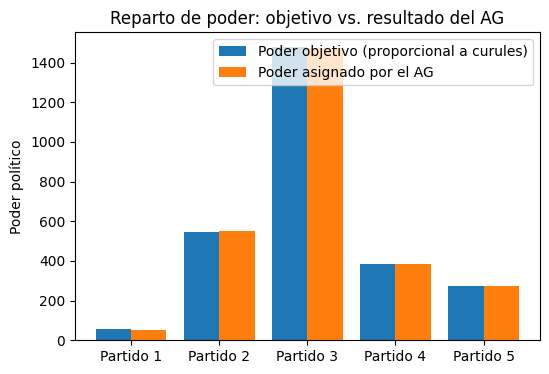

In [ ]:
# Convergencia del AG
plt.figure(figsize=(6,4))
plt.plot(historial2)
plt.xlabel("Generación")
plt.ylabel("Aptitud del mejor individuo")
plt.title("Convergencia del AG - Ejercicio 2")
plt.grid(True)
plt.show()

# Comparación gráfica: poder objetivo vs poder final
x = np.arange(n_partidos)
plt.figure(figsize=(6,4))
plt.bar(x - 0.2, target, width=0.4, label="Poder objetivo (proporcional a curules)")
plt.bar(x + 0.2, poder_final, width=0.4, label="Poder asignado por el AG")
plt.xticks(x, [f"Partido {i+1}" for i in x])
plt.ylabel("Poder político")
plt.legend()
plt.title("Reparto de poder: objetivo vs. resultado del AG")
plt.show()


### Matriz de poder

Se construye la matriz solicitada en el enunciado: filas = entidades, columnas = partidos. Cada celda contiene el peso de la entidad si fue asignada a ese partido, y 0 en caso contrario.

In [ ]:
matriz_poder = np.zeros((n_entidades, n_partidos))
for i, partido in enumerate(mejor_crom):
    matriz_poder[i, partido] = pesos_entidades[i]

print("Matriz de poder (50 entidades x 5 partidos):")
print(matriz_poder)

print("\nSuma por columna (poder total por partido):")
print(matriz_poder.sum(axis=0))


Matriz de poder (50 entidades x 5 partidos):
[[ 0.  0.  0.  0. 53.]
 [ 0. 25.  0.  0.  0.]
 [ 0.  0. 77.  0.  0.]
 [ 0.  0. 93.  0.  0.]
 [ 0.  0. 77.  0.  0.]
 [ 0.  0. 38.  0.  0.]
 [ 0.  0. 23.  0.  0.]
 [ 0. 61.  0.  0.  0.]
 [ 0.  0. 55.  0.  0.]
 [ 0.  0.  0.  0. 23.]
 [ 0. 23.  0.  0.  0.]
 [ 0.  0.  0.  0.  7.]
 [ 0. 83.  0.  0.  0.]
 [ 0.  0. 91.  0.  0.]
 [ 0. 41.  0.  0.  0.]
 [ 0.  0.  0. 75.  0.]
 [ 0.  0.  0. 72.  0.]
 [ 0.  0.  0.  0. 22.]
 [ 0.  0. 83.  0.  0.]
 [ 0.  0. 92.  0.  0.]
 [ 0.  0. 89.  0.  0.]
 [ 0. 78.  0.  0.  0.]
 [ 0. 22.  0.  0.  0.]
 [ 0.  0. 44.  0.  0.]
 [ 0. 65.  0.  0.  0.]
 [ 0.  0. 69.  0.  0.]
 [ 0.  0.  0. 51.  0.]
 [ 0.  0.  0. 13.  0.]
 [ 0.  0. 31.  0.  0.]
 [ 4.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. 51.]
 [ 0.  0. 98.  0.  0.]
 [ 0. 21.  0.  0.  0.]
 [ 0.  0.  0. 91.  0.]
 [ 0.  0.  0. 83.  0.]
 [49.  0.  0.  0.  0.]
 [ 0.  0. 35.  0.  0.]
 [ 0.  0. 63.  0.  0.]
 [ 0.  0. 58.  0.  0.]
 [ 0.  0.  0.  0. 81.]
 [ 0.  0.  0.  0. 14.]
 [ 0.  0. 79

el AG logra una asignación de entidades a partidos cuyo poder total por partido se aproxima bastante al reparto proporcional ideal (basado en las curules de cada uno), aunque no siempre de forma exacta, porque los pesos de las entidades son valores discretos y no siempre existe una combinación que reparta el poder perfectamente. Esto demuestra cómo un AG puede resolver un problema de asignación combinatoria (similar al problema de la mochila, pero con 5 "mochilas" en lugar de una), sin necesidad de probar las $5^{50}$ combinaciones posibles.